In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# ESN FUNCTIONS
# ============================================================
def generate_esn(
    n_inputs,
    n_reservoir,
    spectral_radius=0.9,
    input_scaling=1.0,
    bias_scaling=1.0,
    connectivity=1.0,
    seed=42,
):
    rng = np.random.default_rng(seed)

    # Input weights: shape (n_reservoir, n_inputs)
    Win = rng.uniform(
        low=-0.5 * input_scaling,
        high=0.5 * input_scaling,
        size=(n_reservoir, n_inputs)
    )

    # Bias weights: shape (n_reservoir, 1)
    Wbias = rng.uniform(
        low=-0.5 * bias_scaling,
        high=0.5 * bias_scaling,
        size=(n_reservoir, 1)
    )

    # Reservoir weights
    W = rng.uniform(low=-0.5, high=0.5, size=(n_reservoir, n_reservoir))

    # Sparsify if needed
    if connectivity < 1.0:
        mask = rng.random((n_reservoir, n_reservoir)) < connectivity
        W *= mask

    # Normalize to requested spectral radius
    eigvals = np.linalg.eigvals(W)
    rho = np.max(np.abs(eigvals))
    if rho > 0:
        W *= spectral_radius / rho
    else:
        raise ValueError("Reservoir spectral radius is zero; try a different seed/connectivity.")

    return Win, W, Wbias


def esn_step(x, u, Win, W, Wbias, leak_rate):
    """
    One ESN state update.
    x: (n_reservoir, 1)
    u: (n_inputs, 1)
    """
    preactivation = Win @ u + W @ x + Wbias
    x_new = (1.0 - leak_rate) * x + leak_rate * np.tanh(preactivation)
    return x_new


def fit_esn(X_train, Y_train, Win, W, Wbias, leak_rate=1.0, washout=100, ridge=1e-8):
    """
    Train readout with ridge regression.

    X_train: (T, n_inputs)
    Y_train: (T, n_outputs)
    """
    T = X_train.shape[0]
    n_res = W.shape[0]
    n_inputs = X_train.shape[1]

    x = np.zeros((n_res, 1))

    X_collect = []
    Y_collect = []

    for t in range(T):
        u = X_train[t].reshape(n_inputs, 1)
        x = esn_step(x, u, Win, W, Wbias, leak_rate)

        if t >= washout:
            extended_state = np.vstack([
                np.ones((1, 1)),  # bias term for readout
                u,
                x
            ])[:, 0]
            X_collect.append(extended_state)
            Y_collect.append(Y_train[t])

    X_design = np.array(X_collect).T                  # shape: (1 + n_inputs + n_res, Nsamples)
    Y_target = np.array(Y_collect).T                 # shape: (n_outputs, Nsamples)

    # Ridge regression: Wout = Y X^T (X X^T + beta I)^-1
    A = X_design @ X_design.T + ridge * np.eye(X_design.shape[0])
    B = Y_target @ X_design.T
    Wout = B @ np.linalg.inv(A)

    return Wout


def run_esn_open_loop(X_seq, Win, W, Wbias, Wout=None, leak_rate=1.0, x0=None):
    """
    Run ESN driven by true input sequence.
    Optionally return outputs if Wout is given.

    X_seq: (T, n_inputs)
    """
    T = X_seq.shape[0]
    n_res = W.shape[0]
    n_inputs = X_seq.shape[1]

    x = np.zeros((n_res, 1)) if x0 is None else x0.copy()

    states = []
    outputs = []

    for t in range(T):
        u = X_seq[t].reshape(n_inputs, 1)
        x = esn_step(x, u, Win, W, Wbias, leak_rate)
        states.append(x[:, 0].copy())

        if Wout is not None:
            extended_state = np.vstack([np.ones((1, 1)), u, x])
            y = Wout @ extended_state
            outputs.append(y[:, 0].copy())

    states = np.array(states)

    if Wout is not None:
        outputs = np.array(outputs)
        return states, outputs, x

    return states, x


def predict_closed_loop(initial_input, steps, Win, W, Wbias, Wout, leak_rate=1.0, x0=None):
    """
    Closed-loop ESN prediction:
    each next input is the previous prediction.

    initial_input: shape (n_inputs,) or (n_inputs, 1)
    """
    n_res = W.shape[0]
    n_inputs = Win.shape[1]

    x = np.zeros((n_res, 1)) if x0 is None else x0.copy()
    u = np.asarray(initial_input).reshape(n_inputs, 1)

    Y_pred = []

    for _ in range(steps):
        x = esn_step(x, u, Win, W, Wbias, leak_rate)

        extended_state = np.vstack([np.ones((1, 1)), u, x])
        y = Wout @ extended_state
        Y_pred.append(y[:, 0].copy())

        # closed-loop feedback
        u = y.reshape(n_inputs, 1)

    return np.array(Y_pred), x


def nrmse(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse / (np.std(y_true) + eps)

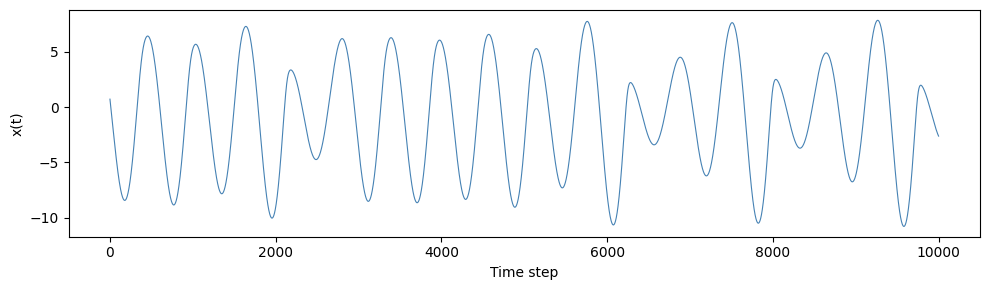

In [24]:
# LOAD DATA
# data should be a 1D numpy array
dataset = np.loadtxt('../data/chaotic_data/rossler_system.csv', delimiter=',')
dataset = dataset[: ,1]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Time step')
ax.set_ylabel('x(t)')
plt.tight_layout()
plt.show()

Train interval : [0 : 2000]
Test interval  : [2000 : 4000]
Warmup length  : 200
Pred. length   : 1800
MSE   : 0.0208419209
RMSE  : 0.1443673124
NRMSE : 0.6150194997


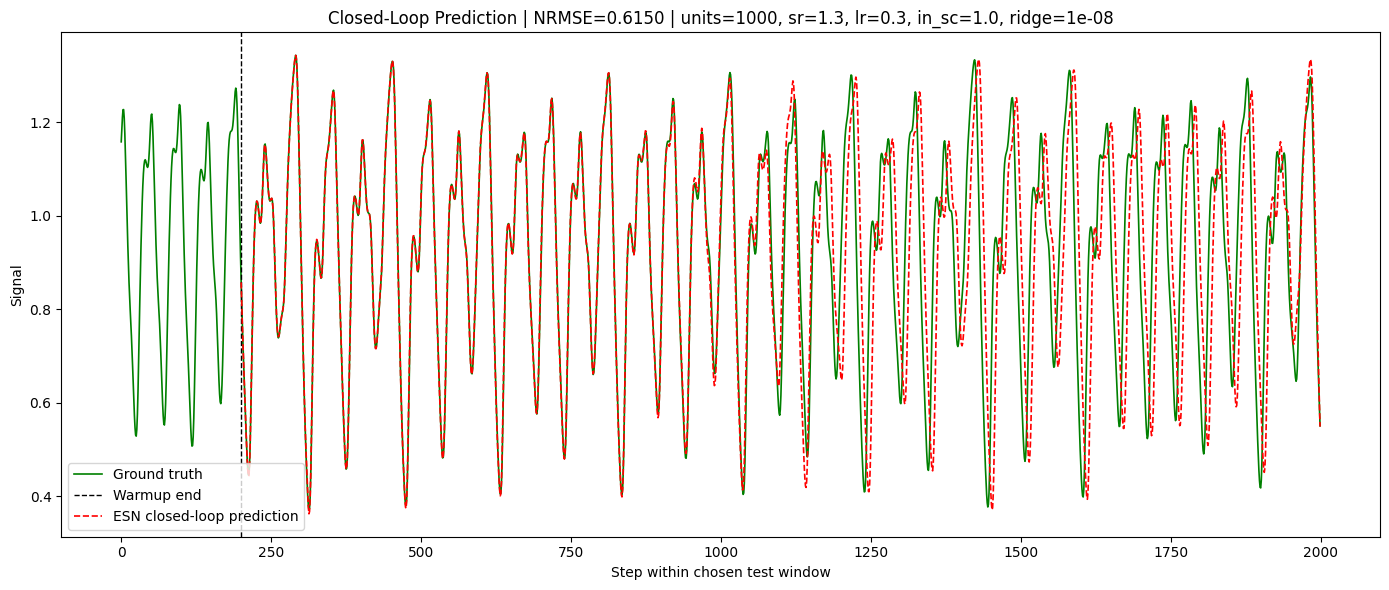

In [2]:
# ============================================================
# USER PARAMETERS
# ============================================================
train_len = 2000   # training uses data[0:train_len]
test_start = 2000  # start index of test window in the full dataset
test_len = 2000    # total length of chosen test window
warmup_len = 200   # first part of test window used for synchronization
ridge_coef = 1e-8

res_units = 1000
leak_rate = 0.3
spectral_radius = 1.3
input_scaling = 1.0
bias_scaling = 1.0
connectivity = 1.0
seed = 42

train_washout = 100

# DATA PREPARATION
data = dataset.reshape(-1, 1)
# X[t] = data[t], Y[t] = data[t+1]
X = data[:-1]
Y = data[1:]

# Training split
X_train = X[:train_len]
Y_train = Y[:train_len]

# Test window
X_test = X[test_start:test_start + test_len]
Y_test = Y[test_start:test_start + test_len]


# ============================================================
# ESN DEFINITION
# ============================================================
Win, W, Wbias = generate_esn(
    n_inputs=X.shape[1],
    n_reservoir=res_units,
    spectral_radius=spectral_radius,
    input_scaling=input_scaling,
    bias_scaling=bias_scaling,
    connectivity=connectivity,
    seed=seed,
)


# ============================================================
# TRAINING
# ============================================================
Wout = fit_esn(
    X_train=X_train,
    Y_train=Y_train,
    Win=Win,
    W=W,
    Wbias=Wbias,
    leak_rate=leak_rate,
    washout=train_washout,
    ridge=ridge_coef,
)


# ============================================================
# TESTING ON AN ARBITRARY WINDOW
# ============================================================
# 1) reset ESN state
x_test = np.zeros((res_units, 1))

# 2) warm up with the first warmup_len true samples of the test window
if warmup_len > 0:
    _, _, x_test = run_esn_open_loop(
        X_seq=X_test[:warmup_len],
        Win=Win,
        W=W,
        Wbias=Wbias,
        Wout=Wout,
        leak_rate=leak_rate,
        x0=x_test
    )

# 3) start closed-loop prediction from the next point
pred_len = test_len - warmup_len

current_input = X_test[warmup_len]   # first seed after warmup

Y_pred, _ = predict_closed_loop(
    initial_input=current_input,
    steps=pred_len,
    Win=Win,
    W=W,
    Wbias=Wbias,
    Wout=Wout,
    leak_rate=leak_rate,
    x0=x_test
)

# Ground truth aligned with prediction interval
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]
Y_pred = Y_pred[:, 0]


# ============================================================
# ERROR METRICS
# ============================================================
mse = np.mean((Y_true - Y_pred) ** 2)
rmse = np.sqrt(mse)
nrmse_val = rmse / (np.std(Y_true) + 1e-12)

print(f"Train interval : [0 : {train_len}]")
print(f"Test interval  : [{test_start} : {test_start + test_len}]")
print(f"Warmup length  : {warmup_len}")
print(f"Pred. length   : {pred_len}")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse_val:.10f}")


# ============================================================
# VISUALIZATION
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    np.arange(test_len),
    Y_test[:, 0],
    c='green',
    label="Ground truth",
    linewidth=1.2
)

ax.axvline(
    warmup_len,
    linestyle="--",
    c='k',
    linewidth=1.0,
    label="Warmup end"
)

ax.plot(
    np.arange(warmup_len, warmup_len + pred_len),
    Y_pred,
    linestyle="--",
    c='red',
    linewidth=1.2,
    label="ESN closed-loop prediction"
)

ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse_val:.4f} | "
    f"units={res_units}, sr={spectral_radius}, "
    f"lr={leak_rate}, in_sc={input_scaling}, "
    f"ridge={ridge_coef:.0e}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()